Repaso 
* Estimación puntual
* Estimación por momentos
    * Igualarmomentos poblacionales ($E(x^k)$) con los muestrales.

La función de densidad de probabilidad para una variable aleatoria continua $X$ con una **distribución gama** y parámetros $\alpha$ (forma) y $\beta$ (escala) se define mediante la siguiente expresión:

$$f(x;\alpha, \beta) = \begin{cases} \frac{1}{\beta^\alpha \Gamma(\alpha)} x^{\alpha-1} e^{-x/\beta} & x \ge 0 \\ 0 & \text{de lo contrario} \end{cases}$$

Donde los parámetros deben cumplir las condiciones $\alpha > 0$ y $\beta > 0$. En esta fórmula, $\Gamma(\alpha)$ representa la **función gama**, la cual se define para $\alpha > 0$ como la integral $\Gamma(\alpha) = \int_{0}^{\infty} x^{\alpha-1} e^{-x} dx$.

## Ejemplo 1

Para desarrollar completamente el **Ejemplo 6.13** sobre la estimación de parámetros en una distribución gama, primero realizaremos la demostración analítica de los momentos poblacionales y luego aplicaremos el método de momentos con los datos proporcionados en las fuentes.

### 1. Demostración analítica de $E(X)$ y $E(X^2)$

La función de densidad de probabilidad (fdp) de una variable aleatoria gama es:
$$f(x; \alpha, \beta) = \frac{1}{\beta^\alpha \Gamma(\alpha)} x^{\alpha-1} e^{-x/\beta}, \quad x \ge 0$$

#### A. Cálculo del primer momento ($E(X)$):
Por definición:
$$E(X) = \int_{0}^{\infty} x \cdot \frac{1}{\beta^\alpha \Gamma(\alpha)} x^{\alpha-1} e^{-x/\beta} dx = \frac{1}{\beta^\alpha \Gamma(\alpha)} \int_{0}^{\infty} x^\alpha e^{-x/\beta} dx$$
Realizando el cambio de variable $u = x/\beta$ (donde $dx = \beta du$):
$$E(X) = \frac{1}{\beta^\alpha \Gamma(\alpha)} \int_{0}^{\infty} (\beta u)^\alpha e^{-u} (\beta du) = \frac{\beta^{\alpha+1}}{\beta^\alpha \Gamma(\alpha)} \int_{0}^{\infty} u^\alpha e^{-u} du$$
La integral $\int_{0}^{\infty} u^\alpha e^{-u} du$ es por definición $\Gamma(\alpha+1)$. Usando la propiedad $\Gamma(\alpha+1) = \alpha\Gamma(\alpha)$:
$$E(X) = \frac{\beta \cdot \alpha\Gamma(\alpha)}{\Gamma(\alpha)} = \alpha\beta$$

#### B. Cálculo del segundo momento ($E(X^2)$):
Procediendo de manera similar:
$$E(X^2) = \int_{0}^{\infty} x^2 \cdot \frac{1}{\beta^\alpha \Gamma(\alpha)} x^{\alpha-1} e^{-x/\beta} dx = \frac{1}{\beta^\alpha \Gamma(\alpha)} \int_{0}^{\infty} x^{\alpha+1} e^{-x/\beta} dx$$
Nuevamente, con $u = x/\beta$:
$$E(X^2) = \frac{1}{\beta^\alpha \Gamma(\alpha)} \int_{0}^{\infty} (\beta u)^{\alpha+1} e^{-u} (\beta du) = \frac{\beta^{\alpha+2}}{\beta^\alpha \Gamma(\alpha)} \int_{0}^{\infty} u^{\alpha+1} e^{-u} du$$
La integral resultante es $\Gamma(\alpha+2)$. Usando la propiedad iterada $\Gamma(\alpha+2) = (\alpha+1)\alpha\Gamma(\alpha)$:
$$E(X^2) = \frac{\beta^2 \cdot \alpha(\alpha+1)\Gamma(\alpha)}{\Gamma(\alpha)} = \alpha(\alpha+1)\beta^2$$

---

### 2. Desarrollo del Ejemplo 6.13 (Método de Momentos)

El método de momentos iguala estos resultados teóricos con los momentos calculados de la muestra ($M_k$).

**Sistema de ecuaciones:**
1.  $\bar{X} = \alpha\beta$
2.  $\frac{1}{n} \sum X_i^2 = \alpha(\alpha+1)\beta^2$

**Resolución algebraica:**
Expandiendo la segunda ecuación: $\frac{1}{n} \sum X_i^2 = \alpha^2\beta^2 + \alpha\beta^2$.
Como de la primera ecuación sabemos que $(\alpha\beta)^2 = \bar{X}^2$, sustituimos:
$$\frac{1}{n} \sum X_i^2 = \bar{X}^2 + \alpha\beta^2$$
Dividiendo esta expresión entre la primera ($\bar{X} = \alpha\beta$):
$$\frac{\frac{1}{n} \sum X_i^2 - \bar{X}^2}{\bar{X}} = \frac{\alpha\beta^2}{\alpha\beta} = \beta$$
Esto nos da los estimadores finales:
*   **Estimador de escala:** $\hat{\beta} = \frac{\frac{1}{n} \sum X_i^2 - \bar{X}^2}{\bar{X}}$
*   **Estimador de forma:** $\hat{\alpha} = \frac{\bar{X}}{\hat{\beta}} = \frac{\bar{X}^2}{\frac{1}{n} \sum X_i^2 - \bar{X}^2}$

---

### 3. Aplicación numérica (Datos de sobrevivencia)

Utilizando los datos de tiempo de sobrevivencia de 20 ratones expuestos a radiación:
*   **Tamaño de muestra ($n$):** 20.
*   **Media muestral ($\bar{x}$):** 113.5.
*   **Segundo momento muestral ($M_2$):** $\frac{1}{20} \sum x_i^2 = 14,087.8$.

**Cálculo de estimaciones:**
1.  **Varianza muestral sesgada ($M_2 - \bar{X}^2$):** $14,087.8 - (113.5)^2 = 14,087.8 - 12,882.25 = 1,205.55$.
2.  **Estimación de $\alpha$:**
    $$\hat{\alpha} = \frac{12,882.25}{1,205.55} \approx 10.7$$
3.  **Estimación de $\beta$:**
    $$\hat{\beta} = \frac{1,205.55}{113.5} \approx 10.6$$

**Conclusión:** Basados en el método de momentos, los parámetros estimados para la distribución de sobrevivencia son $\hat{\alpha} = 10.7$ y $\hat{\beta} = 10.6$.

-Graphics-
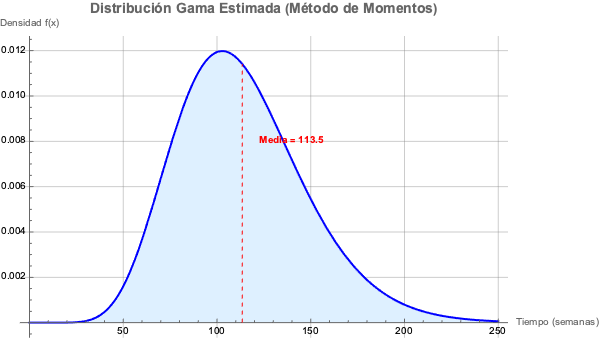

In [8]:
(* Definición de los parámetros estimados por el método de momentos *)
alphaHat = 10.7;
betaHat = 10.6;

(* Creación del gráfico de la distribución Gamma *)
Plot[
  PDF[GammaDistribution[alphaHat, betaHat], x], 
  {x, 0, 250}, 
  PlotStyle -> {Thick, Blue}, 
  Filling -> Axis, 
  FillingStyle -> LightBlue,
  PlotRange -> All, 
  AxesLabel -> {"Tiempo (semanas)", "Densidad f(x)"}, 
  PlotLabel -> Style["Distribución Gama Estimada (Método de Momentos)", 14, Bold],
  Epilog -> {
    Dashed, Red, 
    (* Línea vertical en la media muestral x = 113.5 *)
    Line[{{113.5, 0}, {113.5, PDF[GammaDistribution[alphaHat, betaHat], 113.5]}}],
    Text[Style["Media = 113.5", Bold, Red], {140, 0.008}]
  },
  GridLines -> Automatic,
  Exclusions -> None,
  ImageSize->600
]

El **principio de los mínimos cuadrados** es un método fundamental en estadística para estimar los parámetros de un modelo, buscando que la función de mejor ajuste sea aquella que minimice las distancias verticales entre los puntos observados y dicha función.

A continuación, se detalla la formulación analítica de este método basada en las fuentes:

### 1. El Modelo Probabilístico
Se asume que la variable dependiente $y_i$ está relacionada con una o más variables independientes $x_i$ mediante una función $M(x_i, \theta_j)$ más un término de error aleatorio $\epsilon_i$:
$$y_i = M(x_i, \theta_j) + \epsilon_i$$
Donde:
*   $y_i$: es el valor observado de la variable dependiente.
*   $M(x_i, \theta_j)$: representa la parte determinística del modelo (la "línea de regresión verdadera"), donde $\theta_j$ son los parámetros a estimar (frecuentemente denotados como $\beta_0, \beta_1, \dots, \beta_k$).
*   $\epsilon_i$: es el error aleatorio, que se supone con valor esperado $0$ y varianza constante $\sigma^2$.

### 2. El Criterio de Mínimos Cuadrados
La medida de la "bondad de ajuste" es la suma de los cuadrados de las desviaciones (residuos). El objetivo es encontrar los valores de los parámetros $\theta_j$ que minimicen la siguiente función de error:
$$f(\theta_1, \theta_2, \dots, \theta_j) = \sum_{i=1}^{n} [y_i - M(x_i, \theta_j)]^2$$
En el caso de una **regresión lineal simple**, donde $M(x, \beta_0, \beta_1) = \beta_0 + \beta_1x$, la función a minimizar es:
$$f(b_0, b_1) = \sum_{i=1}^{n} [y_i - (b_0 + b_1x_i)]^2$$

### 3. Resolución: Ecuaciones Normales
Para hallar los valores que minimizan la función, se toman las derivadas parciales con respecto a cada parámetro y se igualan a cero:
*   $\frac{\partial f}{\partial b_0} = \sum 2(y_i - b_0 - b_1x_i)(-1) = 0$
*   $\frac{\partial f}{\partial b_1} = \sum 2(y_i - b_0 - b_1x_i)(-x_i) = 0$

Al reordenar estos términos, se obtiene el sistema de **ecuaciones normales**:
1.  $n b_0 + (\sum x_i) b_1 = \sum y_i$
2.  $(\sum x_i) b_0 + (\sum x_i^2) b_1 = \sum x_i y_i$

### 4. Estimadores de Mínimos Cuadrados
Al resolver el sistema anterior para la regresión lineal, se obtienen las fórmulas para los estimadores puntuales de los parámetros:
*   **Pendiente ($\hat{\beta}_1$):**
    $$\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}$$
*   **Intersección ($\hat{\beta}_0$):**
    $$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### 5. Generalización
Este principio se extiende a modelos más complejos:
*   **Regresión Polinomial:** $M(x, \theta) = \beta_0 + \beta_1x + \dots + \beta_k x^k$. Se minimiza la suma de desviaciones cuadráticas para obtener $k+1$ ecuaciones normales.
*   **Regresión Múltiple:** $M(x_1, \dots, x_k, \theta) = \beta_0 + \beta_1x_1 + \dots + \beta_k x_k$. El procedimiento es análogo, resultando en un sistema de ecuaciones lineales para cada coeficiente.

Los estimadores de mínimos cuadrados son valorados porque, bajo las suposiciones del modelo lineal, son estimadores insesgados de los parámetros poblacionales.

## Ejemplo 2

Para ilustrar el método de **mínimos cuadrados** aplicado a la relación lineal $y = mx + b$ (donde $m$ es la pendiente $\beta_1$ y $b$ es la intersección $\beta_0$), se procede a minimizar la suma de los errores al cuadrado.

### 1. Definición de la función objetivo $S(m, b)$
El objetivo es encontrar los valores de $m$ y $b$ que minimicen la suma de las desviaciones verticales al cuadrado entre los puntos observados $(x_i, y_i)$ y la línea estimada:

$$S(m, b) = \sum_{i=1}^{n} [y_i - (mx_i + b)]^2$$

### 2. Derivación analítica (Ecuaciones Normales)
Para minimizar $S(m, b)$, se toman las derivadas parciales con respecto a $m$ y $b$ e igualándolas a cero:

*   $\frac{\partial S}{\partial b} = \sum 2(y_i - mx_i - b)(-1) = 0$
*   $\frac{\partial S}{\partial m} = \sum 2(y_i - mx_i - b)(-x_i) = 0$

Al simplificar, se obtiene el sistema de **ecuaciones normales**:
1.  $nb + (\sum x_i)m = \sum y_i$
2.  $(\sum x_i)b + (\sum x_i^2)m = \sum x_iy_i$

---

### 3. Ejemplo numérico (Basado en el Ejemplo 12.4)
Supongamos un estudio sobre la relación entre el peso unitario ($x$) y la porosidad ($y$) del concreto, con una muestra de $n = 15$ observaciones.

**Datos resumidos (Estadísticos de resumen):**
*   $n = 15$
*   $\sum x_i = 1640.1$
*   $\sum y_i = 299.8$
*   $\sum x_i^2 = 179,849.73$
*   $\sum x_iy_i = 32,308.59$

**Cálculo de la pendiente ($m$):**
Utilizamos la fórmula de cálculo para el numerador ($S_{xy}$) y el denominador ($S_{xx}$):
*   $S_{xx} = \sum x_i^2 - \frac{(\sum x_i)^2}{n} = 179,849.73 - \frac{(1640.1)^2}{15} = 521.196$
*   $S_{xy} = \sum x_iy_i - \frac{(\sum x_i)(\sum y_i)}{n} = 32,308.59 - \frac{(1640.1)(299.8)}{15} = -471.542$

$$m = \frac{S_{xy}}{S_{xx}} = \frac{-471.542}{521.196} \approx -0.9047$$

**Cálculo de la intersección ($b$):**
Utilizamos las medias muestrales $\bar{x} = 109.34$ y $\bar{y} = 19.987$:
$$b = \bar{y} - m\bar{x} = 19.987 - (-0.9047)(109.34) \approx 118.91$$

### 4. Resultado final
La línea de regresión estimada que minimiza la función $S(m, b)$ es:
$$\hat{y} = -0.905x + 118.91$$

**Interpretación:** Se estima que por cada incremento de una unidad en el peso unitario ($x$), la porosidad ($y$) disminuye en promedio **0.905** unidades. El valor de **118.91** representa la porosidad estimada si el peso unitario fuera cero (intercepción teórica).

Resultados de la Regresio'n:
Sxx = 521.196
Sxy = -471.542
Pendiente (m) = -0.904731
Interseccio'n (b) = 118.91
Ecuacio'n estimada: y = -0.904731x + 118.91


-Graphics-
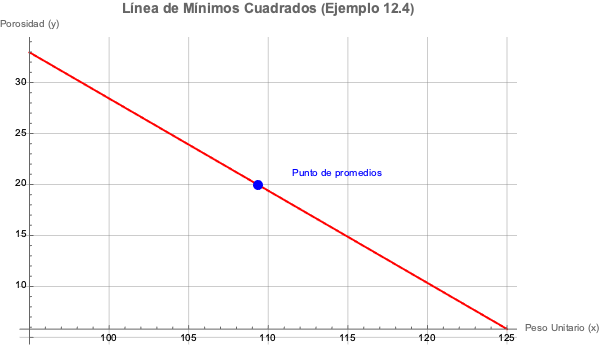

In [45]:
(* 1. Definición de estadísticos de resumen proporcionados *)
n = 15;
sumX = 1640.1;
sumY = 299.8;
sumX2 = 179849.73;
sumXY = 32308.59;

(* 2. Cálculos analíticos de Sxx y Sxy *)
sxx = sumX2 - (sumX^2 / n);
sxy = sumXY - (sumX * sumY / n);

(* 3. Estimación de parámetros (m = pendiente, b = intersección) *)
m = sxy / sxx;
xBar = sumX / n;
yBar = sumY / n;
b = yBar - m * xBar;

(* 4. Impresión de resultados *)
Print["Resultados de la Regresión:"];
Print["Sxx = ", sxx];
Print["Sxy = ", sxy];
Print["Pendiente (m) = ", m];
Print["Intersección (b) = ", b];
Print["Ecuación estimada: y = ", m, "x + ", b];

(* 5. Gráfico de la línea de regresión *)
Plot[m*x + b, {x, 95, 125}, 
 PlotStyle -> {Thick, Red}, 
 AxesLabel -> {"Peso Unitario (x)", "Porosidad (y)"}, 
 PlotLabel -> Style["Línea de Mínimos Cuadrados (Ejemplo 12.4)", 14, Bold], 
 GridLines -> Automatic,
 Epilog -> {
   Blue, PointSize[0.02], 
   Point[{xBar, yBar}], (* Punto de promedios *)
   Text[Style["Punto de promedios", 10, Blue], {xBar + 5, yBar + 1}]
  },
 ImageSize->600
]


FittedModel::notprop: Expression is not a known property for FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]]. Use FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]]["Properties"] for a list of properties.

FittedModel::notprop: Expression is not a known property for FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]]. Use FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]]["Properties"] for a list of properties.

FittedModel::notprop: Expression is not a known property for FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]]. Use FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]]["Properties"] for a list of properties.

General::stop: Further output of FittedModel::notprop will be suppressed during this calculation.

La ecuacio'n de la li'nea de mi'nimos cuadrados es: y = 
 
>   FittedModel[Panel[118.91 - 0.904731 x, FrameMargins -> 5]][Expression]


Legended[Legended[-Graphics-, Placed[PointLegend[{Directive[AbsoluteThickness[1.6], 
 
>        PointSize[Medium], RGBColor[0, 0, 1]]}, {Datos observados}, 
 
>      LegendMarkers -> {{False, Automatic}}, Joined -> {False}, LabelStyle -> {}, 
 
>      LegendLayout -> Column], After, Identity]], 
 
>   Placed[LineLegend[{Directive[Opacity[1.], AbsoluteThickness[1.6], Thickness[Large], 
 
>       RGBColor[1, 0, 0]]}, {Línea de mínimos cuadrados}, LegendMarkers -> None, 
 
>     LabelStyle -> {}, LegendLayout -> Column], After, Identity]]
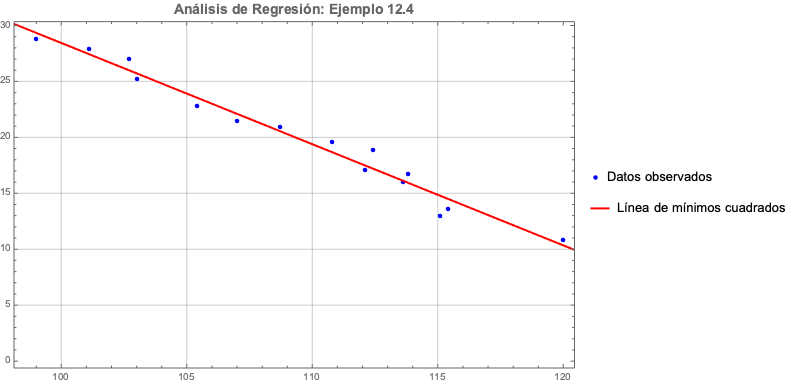

In [36]:
(* 1. Definición de los datos numéricos originales del Ejemplo 12.4 *)
datos = {
  {99.0, 28.8}, {101.1, 27.9}, {102.7, 27.0}, {103.0, 25.2}, 
  {105.4, 22.8}, {107.0, 21.5}, {108.7, 20.9}, {110.8, 19.6}, 
  {112.1, 17.1}, {112.4, 18.9}, {113.6, 16.0}, {113.8, 16.7}, 
  {115.1, 13.0}, {115.4, 13.6}, {120.0, 10.8}
};

(* 2. Creación del modelo de regresión lineal simple *)
modelo = LinearModelFit[datos, x, x];

(* 3. Extracción de la ecuación estimada *)
ecuacion = modelo["Expression"];
Print["La ecuación de la línea de mínimos cuadrados es: y = ", ecuacion];

(* 4. Generación del gráfico completo *)
Show[
  (* Gráfico de los puntos observados *)
  ListPlot[datos, 
    PlotStyle -> {PointSize[Medium], Blue}, 
    PlotLegends -> {"Datos observados"}],
    
  (* Gráfico de la línea de regresión *)
  Plot[modelo[x], {x, 95, 125}, 
    PlotStyle -> {Thick, Red}, 
    PlotLegends -> {"Línea de mínimos cuadrados"}],
  
  (* Configuración visual *)
  AxesLabel -> {"Peso Unitario (x)", "Porosidad (y)"}, 
  PlotLabel -> Style["Análisis de Regresión: Ejemplo 12.4", 14, Bold], 
  GridLines -> Automatic, 
  Frame -> True,
  ImageSize -> Large
]

El método de **estimación de máxima verosimilitud** (EMV) fue introducido por R. A. Fisher en la década de 1920 y es ampliamente recomendado por los estadísticos debido a que sus estimadores poseen propiedades de eficiencia deseables, especialmente cuando el tamaño de la muestra es grande.

### Concepto Fundamental
A diferencia del método de momentos, que iguala características muestrales con poblacionales, la estimación de máxima verosimilitud busca responder a la pregunta: "¿Con qué valor de los parámetros es más probable que haya ocurrido la muestra observada?". El objetivo es seleccionar los valores de los parámetros que "más concuerdan" con los datos recolectados.

### Definición Analítica
Sean $X_1, \dots, X_n$ variables aleatorias con una función de masa de probabilidad (fmp) o función de densidad de probabilidad (fdp) conjunta $f(x_1, \dots, x_n; \theta_1, \dots, \theta_m)$, donde los parámetros $\theta_i$ son desconocidos.

1.  **Función de Verosimilitud:** Cuando se consideran los valores muestrales $x_1, \dots, x_n$ como fijos y la función depende únicamente de los parámetros $\theta_i$, esta se denomina *función de verosimilitud*.
2.  **Estimaciones de Máxima Verosimilitud (emv):** Son los valores de los parámetros que maximizan dicha función.
3.  **Estimadores de Máxima Verosimilitud:** Se obtienen al sustituir los valores observados $x_i$ por las variables aleatorias $X_i$ en las fórmulas resultantes.

### Procedimiento de Cálculo
Dado que maximizar una función es equivalente a maximizar su logaritmo natural (una función monotónica), es práctica común trabajar con el **logaritmo de la verosimilitud** (ln-verosimilitud) para convertir productos en sumas y facilitar las derivadas. El procedimiento general consiste en:
*   Formar la función de verosimilitud (generalmente el producto de las fdp/fmp individuales por la independencia de la muestra).
*   Calcular el logaritmo natural de la función.
*   Obtener las derivadas parciales con respecto a cada parámetro, igualarlas a cero y resolver el sistema de ecuaciones.

### Principio de Invarianza
Una propiedad muy útil es el **principio de invarianza**: si $\hat{\theta}_1, \dots, \hat{\theta}_m$ son los estimadores de máxima verosimilitud de los parámetros $\theta_1, \dots, \theta_m$, entonces el estimador de máxima verosimilitud de cualquier función $h(\theta_1, \dots, \theta_m)$ es simplemente la función evaluada en dichos estimadores: $h(\hat{\theta}_1, \dots, \hat{\theta}_m)$. Por ejemplo, si el EMV de la varianza es $\hat{\sigma}^2$, el EMV de la desviación estándar será $\sqrt{\hat{\sigma}^2}$.

### Propiedades y Complicaciones
*   **Comportamiento con muestra grande:** Bajo condiciones generales, cuando $n$ es grande, el EMV es aproximadamente insesgado y su varianza es casi tan pequeña como la que puede lograr cualquier otro estimador (se aproxima al estimador insesgado con varianza mínima).
*   **Limitaciones del cálculo:** En ocasiones, el máximo de la verosimilitud ocurre en puntos de discontinuidad (como en la distribución uniforme), por lo que no se pueden usar derivadas y se debe identificar el máximo mediante análisis gráfico o directo.
*   **Métodos numéricos:** Para distribuciones como la **Weibull**, las ecuaciones resultantes no tienen solución explícita y requieren procedimientos numéricos iterativos.

## Ejemplo 3 

Descubrió 10 cometas.
El primero, tercero y décimo son de periodo corto.

Quiero estimar la proporción de todos los cometas del sistema solar de periodo corto

Sea $Y$ variable aleatoria de tipo Bernoulli

Y = 1 si es de periodo corto, Y=0 si no lo es

Para desarrollar este ejemplo de **Estimación de Máxima Verosimilitud (EMV)** basado en el descubrimiento de 10 cometas, seguiremos el procedimiento analítico detallado en las fuentes para una distribución de Bernoulli (específicamente el ejemplo 6.15 del texto).

### 1. Definición del problema y de la muestra
Tenemos una muestra de $n = 10$ cometas. Se define la variable aleatoria $Y$ como de tipo Bernoulli, donde:
*   $Y = 1$ (periodo corto) con probabilidad $p$.
*   $Y = 0$ (no es periodo corto) con probabilidad $1 - p$.

Los datos observados ($y_1, y_2, \dots, y_{10}$) según el enunciado son:
1, 0, 1, 0, 0, 0, 0, 0, 0, 1.
Esto nos da un total de **3 éxitos** (periodo corto) y **7 fracasos**.

### 2. Formulación de la Función de Verosimilitud
La función de masa de probabilidad conjunta para una muestra independiente de variables Bernoulli es el producto de las probabilidades individuales. Para esta muestra específica, la función de verosimilitud $f$ es:
$$f(y_1, \dots, y_{10}; p) = p \cdot (1-p) \cdot p \cdot (1-p) \cdot (1-p) \cdot (1-p) \cdot (1-p) \cdot (1-p) \cdot (1-p) \cdot p$$
Simplificando los exponentes por el número de éxitos y fracasos:
$$f(y_1, \dots, y_{10}; p) = p^3(1-p)^7 \text{}$$

### 3. Maximización mediante el Logaritmo Natural
Para encontrar el valor de $p$ que maximiza esta probabilidad, es más sencillo trabajar con el logaritmo natural de la función (ln-verosimilitud), ya que convierte el producto en una suma:
$$\ln[f(y_1, \dots, y_{10}; p)] = 3 \ln(p) + 7 \ln(1-p) \text{}$$

### 4. Resolución Analítica (Derivación)
Se toma la derivada de la ln-verosimilitud con respecto al parámetro $p$ e igualamos a cero para encontrar el máximo:
$$\frac{d}{dp} [3 \ln(p) + 7 \ln(1-p)] = \frac{3}{p} - \frac{7}{1-p} = 0$$

Resolviendo para $p$:
$$\frac{3}{p} = \frac{7}{1-p}$$
$$3(1-p) = 7p$$
$$3 - 3p = 7p$$
$$3 = 10p$$
$$\hat{p} = \frac{3}{10} = 0.3 \text{}$$

### 5. Conclusión
La **estimación de máxima verosimilitud (emv)** para la proporción de cometas de periodo corto en el sistema solar es **0.3** (o 30%). 

Analíticamente, este es el valor del parámetro que hace que la muestra observada (3 de 10 cometas de periodo corto) sea la "más probable" de haber ocurrido, representando la cifra que "más concuerda" con los datos recolectados. De forma general, para cualquier variable Bernoulli, el estimador de máxima verosimilitud siempre será la proporción muestral $\hat{p} = x/n$.

Lo que se realizó en el ejercicio anterior fue una **Estimación de Máxima Verosimilitud (EMV)**, un método constructivo para obtener estimadores puntuales que busca identificar qué valor de un parámetro desconocido hace que los datos observados sean los más probables de haber ocurrido.

A continuación, se describe conceptualmente el proceso, el resultado obtenido y las preguntas fundamentales que este ejercicio permite responder:

### 1. Descripción Conceptual del Proceso
A diferencia de otros métodos que igualan promedios, la EMV cambia la perspectiva: trata a los datos observados como fijos y al parámetro ($\theta$ o $p$) como la variable. 

*   **La Función de Verosimilitud:** Conceptualizamos una función que representa la probabilidad conjunta de la muestra. En el caso de los 10 cometas, esta función mide qué tan probable es obtener exactamente la secuencia observada (3 éxitos y 7 fracasos) para cada posible valor de la proporción $p$ en el Sistema Solar.
*   **El Criterio de "Concordancia":** El método selecciona aquel valor del parámetro que "más concuerda" con los datos recolectados. Es decir, buscamos la cima de la curva de probabilidad: el punto exacto donde la probabilidad de haber observado esos 10 cometas específicos alcanza su valor máximo.
*   **Simplificación Matemática:** Se utilizó el logaritmo natural (ln-verosimilitud) porque, al ser una función monotónica, el valor de $p$ que maximiza el logaritmo es el mismo que maximiza la función original. Esto permite convertir productos de probabilidades en sumas, facilitando el uso de derivadas para encontrar el máximo.

### 2. El Resultado: ¿Qué valor de $p$ es más probable?
En efecto, mediante este ejercicio **respondimos a la pregunta de cuál es el valor de $p$ más probable**. 
*   **Lo que se obtuvo:** Se obtuvo que $\hat{p} = 0.3$ es la **Estimación de Máxima Verosimilitud (emv)**. 
*   **Significado:** Esto significa que, entre todas las posibles proporciones de cometas de periodo corto (desde 0% hasta 100%), el valor del 30% es el que hace que nuestra muestra de 3 cometas de periodo corto entre 10 observados sea la "más probable" de haber ocurrido. Si la proporción real en el Sistema Solar fuera muy distinta (por ejemplo, 0.8), sería extremadamente improbable haber encontrado solo 3 en una muestra de 10.

### 3. ¿Qué preguntas se responden con este ejercicio?
Este procedimiento no solo arroja un número, sino que resuelve interrogantes estadísticas fundamentales:

1.  **¿Cuál es la "mejor conjetura" (Best Guess)?** Proporciona una estimación puntual, que es un solo número que representa un valor sensible y plausible para el parámetro de la población basado en la información disponible.
2.  **¿Qué tan bien se ajusta el modelo a la realidad?** El ejercicio permite establecer un estimador ($\hat{p} = X/n$) que, según la teoría, tiene propiedades de eficiencia deseables; cuando el tamaño de la muestra crece, este estimador tiende a ser el más preciso posible (varianza mínima).
3.  **¿Cómo podemos estimar funciones relacionadas?** Gracias al **principio de invarianza**, una vez que respondimos que $\hat{p} = 0.3$, podemos responder automáticamente otras preguntas. Por ejemplo, si quisiéramos saber cuál es el valor más probable para la probabilidad de que *ninguno* de los próximos 5 cometas sea de periodo corto, simplemente aplicaríamos la función al resultado obtenido: $(1 - 0.3)^5$.

**En resumen:** Lo que se obtuvo es el valor del parámetro que maximiza la "verosimilitud" de nuestra experiencia empírica, convirtiendo la observación de 10 cometas en una conclusión científica sobre la estructura de toda la población de cometas del sistema solar.

La función de verosimilitud es la función de masa o densidad de probabilidad conjunta de una muestra, considerada específicamente como una función de los parámetros desconocidos $\theta_1, \dots, \theta_m$ cuando los valores muestrales $x_1, \dots, x_n$ son fijos. 

Su objetivo principal es responder a la pregunta de qué valor de los parámetros hace que la muestra observada sea la "más probable" de haber ocurrido. Los valores que maximizan esta función se denominan **estimaciones de máxima verosimilitud (emv)** y representan los parámetros que "más concuerdan" con los datos recolectados. 

Debido a que maximizar una función es equivalente a maximizar su logaritmo, es práctica común utilizar el **logaritmo natural de la verosimilitud** (ln-verosimilitud) para facilitar los cálculos matemáticos, transformando los productos de probabilidades en sumas.

Para visualizar conceptualmente el método de **estimación de máxima verosimilitud (EMV)** aplicado al ejemplo de los 10 cometas (donde se observaron 3 de periodo corto), se grafica la función de verosimilitud $L(p) = p^3(1-p)^7$. El objetivo es identificar el punto más alto de la curva, el cual corresponde al valor del parámetro que hace que la muestra observada sea la más probable.

A continuación se presenta el script de **Wolfram Language** para generar este gráfico:

-Graphics-
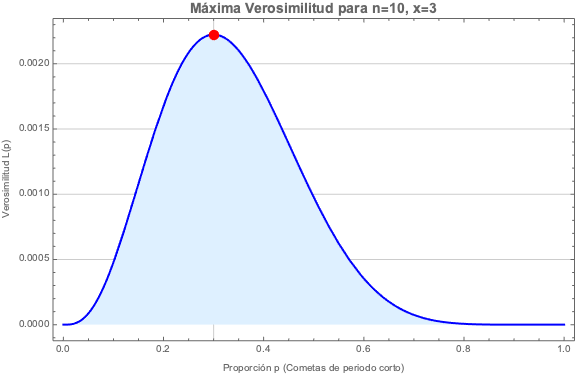

In [72]:
(* Definición de la función de verosimilitud L(p) para 3 éxitos en 10 ensayos *)
verosimilitud[p_] := p^3 * (1 - p)^7;

(* Generación del gráfico *)
Plot[verosimilitud[p], {p, 0, 1}, 
 PlotStyle -> {Thick, Blue}, 
 Filling -> Axis, 
 FillingStyle -> LightBlue,
 Frame -> True,
 FrameLabel -> {"Proporción p (Cometas de periodo corto)", "Verosimilitud L(p)"}, 
 PlotLabel -> Style["Máxima Verosimilitud para n=10, x=3", 14, Bold],
 GridLines -> {{0.3}, Automatic},
 Epilog -> {
   Red, PointSize[0.02], 
   Point[{0.3, verosimilitud[0.3]}], (* Punto del máximo en p = 0.3 *)
   Text[Style["EMV (p = 0.3)", Bold, Red, 12], {0.3, verosimilitud[0.3] * 1.1}]
  },
 PlotRange -> All,
 ImageSize -> Large
]

### Explicación del gráfico:
*   **La Curva:** Representa la probabilidad conjunta de observar exactamente esa secuencia de 10 cometas para cada posible valor de la proporción poblacional $p$.
*   **El Eje Horizontal ($p$):** Muestra el rango de posibles proporciones, desde 0 hasta 1.
*   **El Punto Máximo:** Se localiza en $p = 0.3$, que es la **estimación de máxima verosimilitud**. Analíticamente, este es el valor que "más concuerda" con los datos observados en la muestra.
*   **Área de Verosimilitud:** El gráfico permite ver que valores cercanos a 0.3 son plausibles, mientras que valores extremos (como $p > 0.8$) harían que la muestra observada fuera extremadamente improbable.

Conceptualmente, el resultado $\hat{p} = X/n$ obtenido mediante el método de **Estimación de Máxima Verosimilitud (EMV)** representa el valor del parámetro que hace que los datos observados sean los "más probables" de haber ocurrido.

A continuación se explican los pilares conceptuales de este resultado:

*   **Criterio de "Concordancia":** A diferencia de otros métodos, la EMV busca los valores de los parámetros que "más concuerdan" con los datos recolectados en la realidad. En el caso de una proporción, el resultado nos dice que la frecuencia observada en la muestra ($X/n$) es la apuesta más razonable para representar la proporción real de toda la población.
*   **La Muestra como Evidencia Fija:** En este enfoque, los datos de la muestra se consideran fijos y el parámetro $p$ se trata como la variable. El estimador $\hat{p} = X/n$ es el punto exacto donde la "función de verosimilitud" alcanza su cima, indicando que cualquier otro valor de $p$ haría que nuestra muestra fuera menos probable de obtener.
*   **Eficiencia y Precisión:** Teóricamente, este resultado es muy valorado porque, cuando el tamaño de la muestra es grande, el estimador $\hat{p}$ es aproximadamente insesgado y su varianza es casi tan pequeña como la que puede lograr cualquier otro estimador (se aproxima a un estimador de varianza mínima).
*   **Principio de Invarianza:** Una vez establecido que $\hat{p} = X/n$ es el valor más verosímil para la proporción, este resultado sirve para estimar cualquier función relacionada con ese parámetro simplemente sustituyéndolo en la fórmula respectiva.

El procedimiento analítico para obtener los **Estimadores de Máxima Verosimilitud (EMV)** a partir de la función de verosimilitud se desarrolla en los siguientes pasos fundamentales:

### 1. Definición de la Función de Verosimilitud ($L$)
Dada una muestra aleatoria $X_1, \dots, X_n$ proveniente de una población con función de densidad (o masa) $f(x; \theta_1, \dots, \theta_m)$, la función de verosimilitud representa la probabilidad conjunta de la muestra observada como una función de los parámetros desconocidos $\theta_j$:
$$L(\theta_1, \dots, \theta_m) = f(x_1, \dots, x_n; \theta_1, \dots, \theta_m) = \prod_{i=1}^{n} f(x_i; \theta_1, \dots, \theta_m)$$

### 2. Transformación Logarítmica (ln-verosimilitud)
Puesto que el logaritmo natural ($\ln$) es una función estrictamente creciente (monotónica), el valor de los parámetros que maximiza $\ln(L)$ es el mismo que maximiza a $L$. Esta transformación es analíticamente ventajosa porque convierte el producto de la productoria en una suma:
$$\ln[L(\theta_1, \dots, \theta_m)] = \sum_{i=1}^{n} \ln[f(x_i; \theta_1, \dots, \theta_m)]$$

### 3. Proceso de Maximización (Derivación)
Para hallar los valores que incrementan al máximo la función, se deben tomar las derivadas parciales de la ln-verosimilitud con respecto a cada uno de los $m$ parámetros desconocidos e igualarlas a cero:
$$\frac{\partial \ln L}{\partial \theta_1} = 0, \quad \frac{\partial \ln L}{\partial \theta_2} = 0, \quad \dots, \quad \frac{\partial \ln L}{\partial \theta_m} = 0$$

### 4. Resolución del Sistema de Ecuaciones
Se resuelve el sistema resultante para despejar los parámetros. Los valores obtenidos, denominados **estimaciones de máxima verosimilitud** ($\hat{\theta}_1, \dots, \hat{\theta}_m$), son aquellos que "más concuerdan" con los datos recolectados. 

*   **Nota analítica:** En casos donde la función de verosimilitud es discontinua (como en la distribución uniforme), el máximo no se encuentra mediante derivadas, sino identificando el punto de discontinuidad que maximiza el valor de la función.

### 5. Definición del Estimador
Finalmente, al sustituir los valores observados $x_i$ por las variables aleatorias $X_i$ en las fórmulas resultantes, se obtienen los **estimadores de máxima verosimilitud**. Estos estimadores poseen propiedades de eficiencia deseables, ya que para muestras grandes son aproximadamente insesgados y de varianza mínima.

## Ejemplo 3

$$X\sim N(x;\mu,\sigma^2)$$


La función de densidad de probabilidad para una variable aleatoria continua $X$ con una **distribución normal** de parámetros $\mu$ (media) y $\sigma$ (desviación estándar) se define como:

$$f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} e^{-(x-\mu)^2/(2\sigma^2)} \quad -\infty < x < \infty \text{}$$

En esta expresión:
*   El parámetro $\mu$ representa el centro de la distribución (media y mediana).
*   El parámetro $\sigma$ (o su cuadrado $\sigma^2$, la varianza) determina la dispersión o el ancho de la campana.
*   Las constantes $e$ y $\pi$ tienen sus valores matemáticos usuales ($\approx 2.71828$ y $\approx 3.14159$, respectivamente).

### Ejemplo 6.17: EMV para la Distribución Normal

Sean $X_1, \dots, X_n$ una muestra aleatoria proveniente de una distribución normal con parámetros desconocidos $\mu$ y $\sigma^2$. La función de masa (o densidad) de probabilidad conjunta, que en este contexto se define como la **función de verosimilitud**, es el producto de las densidades individuales debido a la independencia de la muestra:

$$L(\mu, \sigma^2) = \prod_{i=1}^{n} f(x_i; \mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} e^{-(x_i-\mu)^2/(2\sigma^2)}$$

Al realizar el producto de los términos, la expresión se simplifica a:

$$L(\mu, \sigma^2) = \left( \frac{1}{2\pi\sigma^2} \right)^{n/2} e^{-\sum (x_i-\mu)^2/(2\sigma^2)}$$

#### 1. Transformación Logarítmica (ln-verosimilitud)
Para facilitar la maximización, se aplica el logaritmo natural ($\ln$) a la función de verosimilitud:

$$\ln [L(\mu, \sigma^2)] = -\frac{n}{2} \ln(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2$$

#### 2. Proceso de Maximización
Para determinar los valores de $\mu$ y $\sigma^2$ que maximizan esta función, se deben tomar las derivadas parciales con respecto a cada parámetro e igualarlas a cero:

1.  $\frac{\partial \ln L}{\partial \mu} = 0$
2.  $\frac{\partial \ln L}{\partial \sigma^2} = 0$

#### 3. Estimadores de Máxima Verosimilitud Resultantes
Al resolver el sistema de ecuaciones anterior, se obtienen los siguientes estimadores:

*   **Estimador de la media ($\hat{\mu}$):**
    $$\hat{\mu} = \bar{X}$$
*   **Estimador de la varianza ($\hat{\sigma}^2$):**
    $$\hat{\sigma}^2 = \frac{\sum_{i=1}^{n} (X_i - \bar{X})^2}{n}$$

**Nota importante:** El estimador de máxima verosimilitud de $\sigma^2$ obtenido por este método utiliza el divisor $n$, lo que lo convierte en un **estimador sesgado**. Esto contrasta con el principio de insesgamiento, el cual prefiere el uso de la varianza muestral $S^2$ (que utiliza el divisor $n-1$). Por lo tanto, en este caso, dos principios de estimación diferentes (insesgamiento y máxima verosimilitud) producen resultados distintos.

Maximización respecto a la media ($\mu$)

Se toma la derivada parcial de la log-verosimilitud con respecto a $\mu$ e igualamos a cero:
$$\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu) = 0$$
Resolviendo para $\mu$:
$$\sum x_i - n\mu = 0 \implies n\mu = \sum x_i \implies \hat{\mu} = \frac{\sum x_i}{n} = \bar{X}$$
Por lo tanto, el **estimador de la media** es la media muestral $\bar{X}$.

Maximización respecto a la varianza ($\sigma^2$)

Se toma la derivada parcial respecto a $\sigma^2$ (tratándola como una sola variable) e igualamos a cero:
$$\frac{\partial \ln L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$
Multiplicando por $2(\sigma^2)^2$:
$$-n\sigma^2 + \sum (x_i - \mu)^2 = 0 \implies n\sigma^2 = \sum (x_i - \mu)^2$$
Sustituyendo $\mu$ por su estimador $\bar{X}$, obtenemos el **estimador de la varianza**:
$$\hat{\sigma}^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{X})^2}{n}$$

Conclusión de los Resultados

*   **Estimador de $\mu$:** $\hat{\mu} = \bar{X}$, el cual es insesgado.
*   **Estimador de $\sigma^2$:** $\hat{\sigma}^2 = \frac{\sum (X_i - \bar{X})^2}{n}$, el cual es **sesgado**, ya que el principio de máxima verosimilitud no utiliza el divisor $n-1$ necesario para el insesgamiento.